# Mutações
### Imports

In [2]:
from random import randint, choices, sample, uniform, seed
import numpy as np
import cupy as cp
import cupyx.scipy.ndimage as scimg
import cupyx.scipy.signal as scicon
import math
import imageio.v3 as imio
from PIL import Image, ImageFile, ImageOps
import cv2

import classes.pokedex as pokedex
import classes.mutation as mutation
import classes.utils as utils


%matplotlib inline 
from matplotlib import pyplot as plt


C:\Users\Tobias U-05\AppData\Roaming\Python\Python313\site-packages\cupyx\jit\_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


### Gets

In [3]:

pkd = pokedex.Pokedex(target_dex='809', score_type='rgba')
mut = mutation.Mutation()

9
rgba
<class 'cupy.ndarray'>


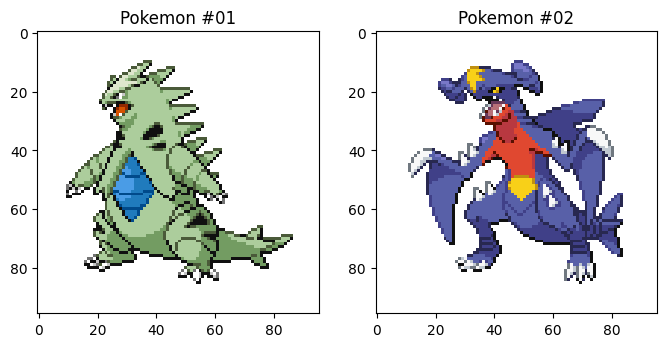

In [4]:
pk1 = pkd.load_pokepng('248')

pk2 = pkd.load_pokepng('445')

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('Pokemon #01')
axis[0].imshow(cp.asnumpy(pk1), interpolation='nearest')
axis[1].set_title('Pokemon #02')
axis[1].imshow(cp.asnumpy(pk2), interpolation='nearest')


plt.show()



## Testes

### Rotações

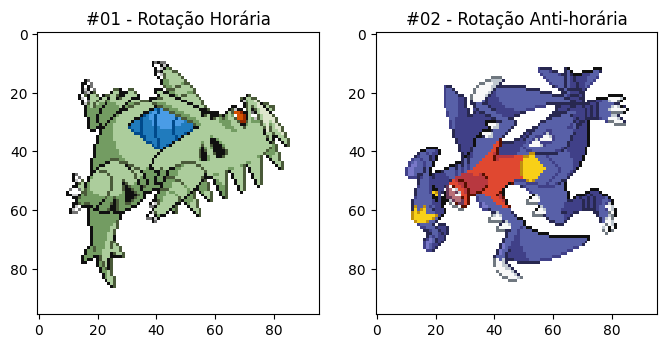

In [5]:
pk_mut1 = cp.rot90(pk1, k=-1)
pk_mut2 = cp.rot90(pk2, k=1)

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Rotação Horária')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Rotação Anti-horária')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')


plt.show()

### Espelhamento

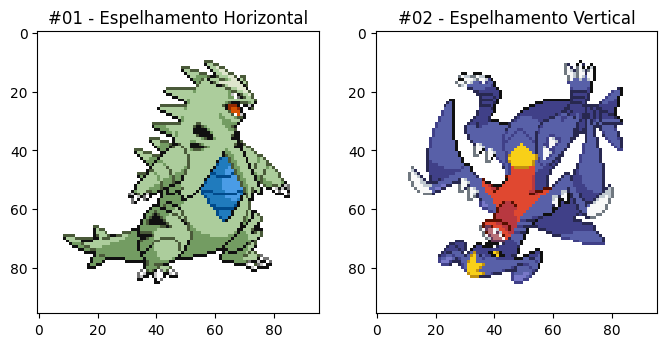

In [6]:
pk_mut1 = cp.fliplr(pk1)
pk_mut2 = cp.flipud(pk2)

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Espelhamento Horizontal')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Espelhamento Vertical')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')


plt.show()

### Espelhamento Divisório

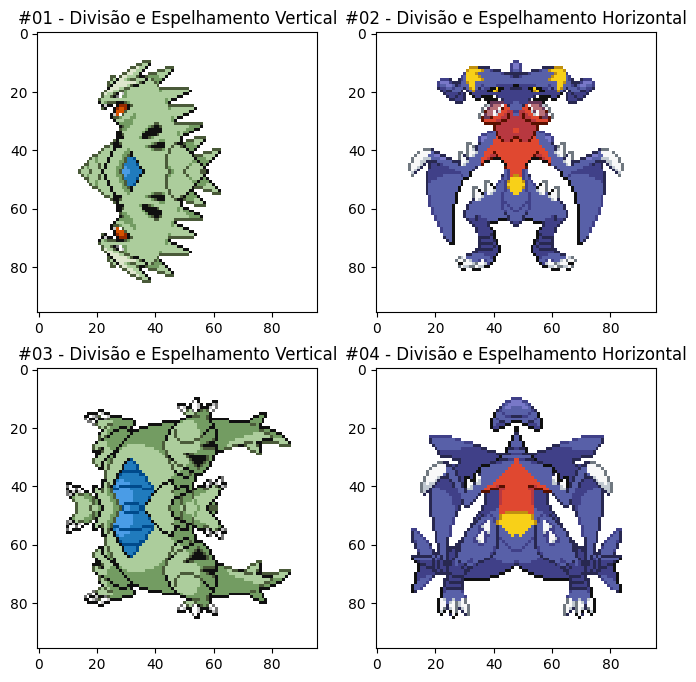

In [7]:
v_half = pk1.shape[0] // 2
pk_mut1a = cp.vstack((pk1[:v_half], cp.flipud(pk1[:v_half])))
pk_mut1b = cp.vstack((cp.flipud(pk1[v_half:]), pk1[v_half:]))
    
h_half = pk2.shape[1] // 2
pk_mut2a = cp.hstack((pk2[:, :h_half], cp.fliplr(pk2[:, :h_half])))
pk_mut2b = cp.hstack((cp.fliplr(pk2[:, h_half:]), pk2[:, h_half:]))
    
    
figure, axis = plt.subplots(2, 2, figsize=(8, 8))
axis[0,0].set_title('#01 - Divisão e Espelhamento Vertical')
axis[0,0].imshow(cp.asnumpy(pk_mut1a), interpolation='nearest')
axis[0,1].set_title('#02 - Divisão e Espelhamento Horizontal')
axis[0,1].imshow(cp.asnumpy(pk_mut2a), interpolation='nearest')
axis[1,0].set_title('#03 - Divisão e Espelhamento Vertical')
axis[1,0].imshow(cp.asnumpy(pk_mut1b), interpolation='nearest')
axis[1,1].set_title('#04 - Divisão e Espelhamento Horizontal')
axis[1,1].imshow(cp.asnumpy(pk_mut2b), interpolation='nearest')


plt.show()

## Filtros
### Gaussian Blur

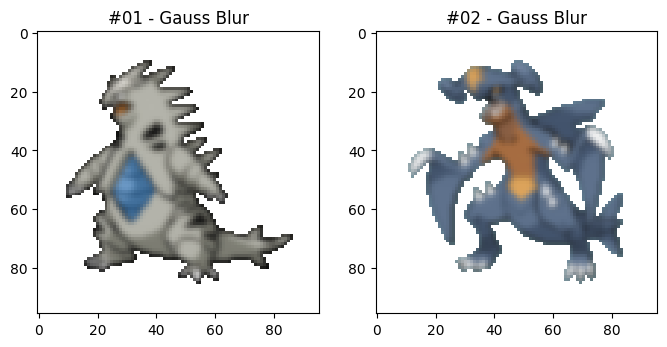

In [36]:
pk_mut1 = cp.copy(pk1)
pk_mut1[:,:,0:3] = scimg.gaussian_filter(pk1[:,:,:3], sigma=1)
pk_mut2 = cp.copy(pk2)
pk_mut2[:,:,0:3] = scimg.gaussian_filter(pk2[:,:,:3], sigma=1)
#mk = pk2[:,:,3] > 0
#pk_mut2[mk,3] = 255

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Gauss Blur')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Gauss Blur')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')

### Box Blur

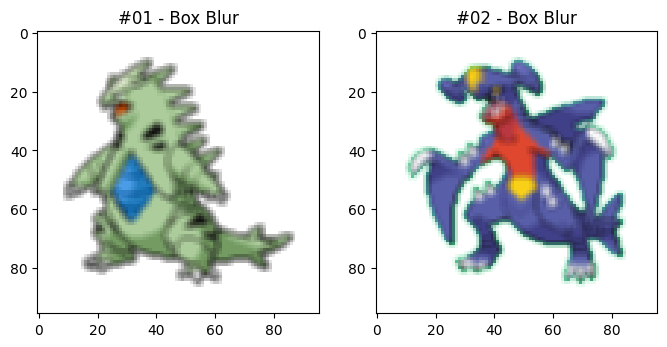

In [44]:
kernel = cp.zeros((3,3,1))
kernel[:,:,0] = cp.array([
    [1.0, 1.0, 1.0],
    [1.0, 1.0, 1.0],
    [1.0, 1.0, 1.0],
])/9.0

pk_mut1 = scimg.convolve(pk1, kernel)
pk_mut2 = scimg.convolve(pk2, kernel)
mk = pk2[:,:,3] > 0
pk_mut2[mk,3] = 255


figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Box Blur')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Box Blur')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')

### Mediana

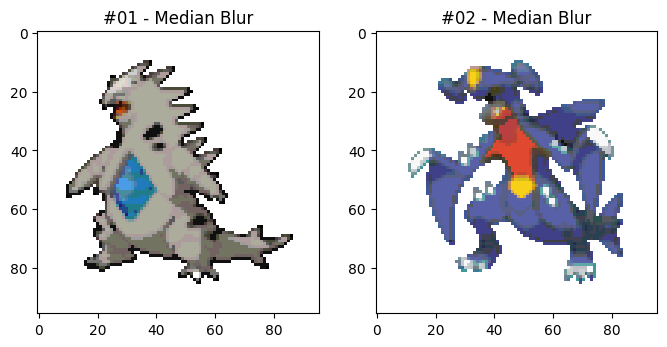

In [ ]:
pk_mut1 = cp.copy(pk1)
pk_mut1[:,:,0:3] = scimg.median_filter(pk1[:,:,:3],size=3)


#pk_mut1 = scimg.convolve(pk1, weights=[])
#pk_mut1 = scicon.convolve2d()
pk_mut2 = cp.copy(pk2)
pk_mut2[:,:,0:3] = scimg.median_filter(pk2[:,:,:3], size=3)
#pk_mut2 = cv2.medianBlur(cp.asnumpy(pk2), 3)


figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Median Blur')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Median Blur')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')

### Sharpen

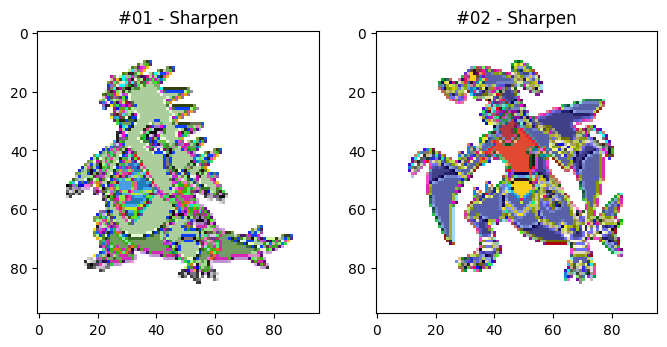

In [63]:
kernel = cp.zeros((3,3,1))
kernel[:,:,0] = cp.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0],
])
pk_mut1 = cp.copy(pk1)
pk_mut1[:,:,:3] = scimg.convolve(pk1[:,:,:3], kernel)
pk_mut2 = cp.copy(pk2)
pk_mut2[:,:,:3] = scimg.convolve(pk2[:,:,:3], kernel)


figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Sharpen')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Sharpen')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')

## Outros
### Shuffle

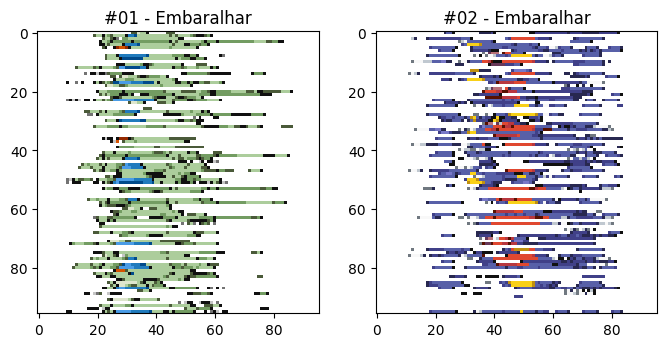

In [68]:

pk_mut1 = cp.copy(pk1)
pk_mut2 = cp.copy(pk2)
cp.random.shuffle(pk_mut1)
cp.random.shuffle(pk_mut2)

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Embaralhar')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Embaralhar')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')


### Inverter

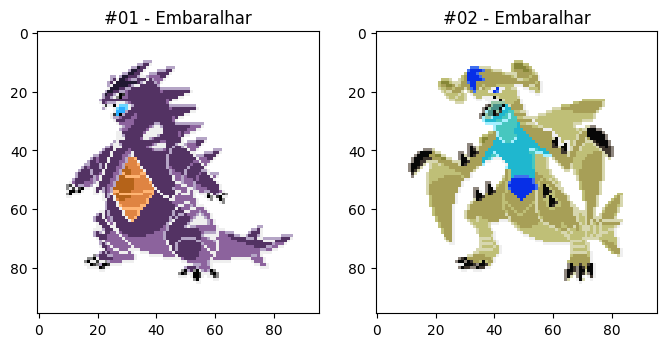

In [ ]:
pk_mut1 = cp.copy(pk1)
pk_mut2 = cp.copy(pk2)

mk1 = pk1[:,:,3] != 255
mk2 = pk2[:,:,3] != 255
pk_mut1[:,:,:3] = cp.bitwise_not(pk1[:,:,:3])
pk_mut2[:,:,:3] = cp.bitwise_not(pk2[:,:,:3])

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Inverter')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Inverter')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')


In [ ]:
def mutate(self, pk_img):
        
        mutation_type = randint(0, 10)
        #print(f'Tipo de mutação:{mutation_type}')
        match mutation_type:
            #case 5:
                #pk_img = utils.to_rgba(utils.to_grayscale(pk_img))
            #case 6:
                #pk_img = utils.to_rgba(utils.to_black_n_white(pk_img))
            #case 7:
                #pk_img = utils.posterize(pk_img)
            #case 8:
                #pk_img = utils.posterize_hard(pk_img)
            #case 9:
                #cl = choices([(True, False, False), (False, True, False), (False, False, True), (True, True, False), (True, False, True), (False, True, True)], k=1)
                #pk_img = utils.to_monochrome(pk_img, cl[0][0], cl[0][1], cl[0][2])
            #case 10:
                #pk_img = self.random_aberration(pk_img=pk_img)
            #case 11:
                #pk_img = self.statistic_aberration(pk_img=pk_img)
            #case 12:
                #pk_img = utils.fit_img(pk_img)
            #case 11: 
            #    st_e = cv2.getStructuringElement(cv2.MORPH_CROSS,(3,3))
            #    pk_img = cp.asarray(cv2.erode(cp.asnumpy(pk_img), st_e, iterations=randint(1,3)))
            #case 12:
            #    st_e = cv2.getStructuringElement(cv2.MORPH_CROSS,(3,3))
            #    pk_img = cp.asarray(cv2.dilate(cp.asnumpy(pk_img), st_e, iterations=randint(1,3)))
            #case 21:
                #st_e = cv2.getStructuringElement(cv2.MORPH_CROSS,(3,3))
                #pk_img = cv2.morphologyEx(pk_img, cv2.MORPH_CLOSE, st_e, iterations=randint(1,2))
            #case 22:
                #st_e = cv2.getStructuringElement(cv2.MORPH_CROSS,(3,3))
                #pk_img = cv2.morphologyEx(pk_img, cv2.MORPH_OPEN, st_e, iterations=randint(1,2))
            #case 23:
                #st_e = cv2.getStructuringElement(cv2.MORPH_CROSS,(3,3))
                #pk_img = cv2.morphologyEx(pk_img, cv2.MORPH_GRADIENT, st_e)
            #case 24:
                #st_e = cv2.getStructuringElement(cv2.MORPH_CROSS,(3,3))
                #pk_img = cv2.morphologyEx(pk_img, cv2.MORPH_TOPHAT, st_e)
            #case 25:
                #st_e = cv2.getStructuringElement(cv2.MORPH_CROSS,(3,3))
                #pk_img = cv2.morphologyEx(pk_img, cv2.MORPH_BLACKHAT, st_e)
            #case 28:
                ####gauss = scimg.gaussian_filter(pk_img, sigma=2)
                #gauss = cv2.GaussianBlur(np.copy(pk_img), (3,3),0)
                #mk = gauss[:,:,3] > 0
                #pk_img = cv2.addWeighted(pk_img, 2.0, gauss, -1.0, 0)
                #pk_img[mk,3] = 255
            #case 29:
                #pk_img = self.visible_mono(pk_img)
            #case 30:
                #pk_img = utils.bayer_dithering_RGB(pk_img)
            #case 31:
                #pk_img = utils.bayer_dithering_BY(pk_img)
            #case 32:
                #pk_img = cp.bitwise_not(pk_img)
                #pk_img = cv2.bitwise_not(pk_img)        
        
        #if randint(0,9) == 9:
        #    pk_img = self.mutate(pk_img=pk_img)
        
        return pk_img